In [2]:
# =============================================================================
# MULTIPLE MYELOMA SURVIVAL — MODELING
# =============================================================================
# This notebook implements two parallel modeling strategies to predict
# survival outcomes (OS and EFS at 24 months) from gene expression data.
#
# Strategy A — Cluster scores (20 features):
#   Uses the mean expression of each of the 20 gene clusters identified
#   in the EDA as features. Biologically interpretable — each feature
#   represents a gene expression pathway.
#
# Strategy B — LASSO feature selection:
#   Uses LASSO regression to select genes directly associated with survival
#   from the full 21,655 gene matrix. More granular — features are individual
#   genes rather than pathways.
#
# Both strategies are evaluated on the predefined Validation set (214 patients)
# and tracked with MLflow for experiment comparison.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# MLflow setup
mlflow.set_tracking_uri(f"file:///home/miguel/myeloma-survival-genomics/mlruns")
mlflow.set_experiment("myeloma_survival")



<Experiment: artifact_location='file:///home/miguel/myeloma-survival-genomics/mlruns/968593698346197276', creation_time=1772705472927, experiment_id='968593698346197276', last_update_time=1772705472927, lifecycle_stage='active', name='myeloma_survival', tags={}, workspace='default'>

In [3]:
# =============================================================================
# DATA LOADING AND FEATURE PREPARATION
# =============================================================================
# Datasets loaded:
#   df_clinical   — 559 patients x 7 clinical features (age, sex, OS, EFS,
#                   training/validation split)
#   df_expr       — 559 patients x 21,655 genes (log2 expression values)
#
# After removing 5 MAQC_Remove patients:
#   Training set  — 340 patients, used to fit all models
#   Validation set — 214 patients, used to evaluate all models
#                    (predefined split from the original study)
#
# Targets (binary classification):
#   y_train_os / y_val_os   — Overall Survival at 24 months
#                             1 = deceased, 0 = alive
#   y_train_efs / y_val_efs — Event-Free Survival at 24 months
#                             1 = relapse/progression, 0 = no event
# =============================================================================

# Load data
df_clinical = pd.read_csv('../data/clinical_data.csv')
df_expr = pd.read_csv('../data/expression_matrix.csv', index_col='sample_id')

print(f"Clinical data: {df_clinical.shape}")
print(f"Expression matrix: {df_expr.shape}")

# Exclude MAQC_Remove patients
df_clinical = df_clinical[df_clinical['split'] != 'MAQC_Remove'].reset_index(drop=True)
print(f"\nAfter removing MAQC_Remove: {df_clinical.shape}")

# Train/Validation split
train_ids = df_clinical[df_clinical['split'] == 'Training']['sample_id'].values
val_ids = df_clinical[df_clinical['split'] == 'Validation']['sample_id'].values

print(f"Training: {len(train_ids)} patients")
print(f"Validation: {len(val_ids)} patients")

# Targets
y_train_os = df_clinical[df_clinical['split'] == 'Training']['os_24m'].values
y_val_os = df_clinical[df_clinical['split'] == 'Validation']['os_24m'].values
y_train_efs = df_clinical[df_clinical['split'] == 'Training']['efs_24m'].values
y_val_efs = df_clinical[df_clinical['split'] == 'Validation']['efs_24m'].values

print(f"\nOS 24m — Train: {y_train_os.sum()} events ({y_train_os.mean()*100:.1f}%)")
print(f"OS 24m — Val:   {y_val_os.sum()} events ({y_val_os.mean()*100:.1f}%)")
print(f"\nEFS 24m — Train: {y_train_efs.sum()} events ({y_train_efs.mean()*100:.1f}%)")
print(f"EFS 24m — Val:   {y_val_efs.sum()} events ({y_val_efs.mean()*100:.1f}%)")

Clinical data: (559, 7)
Expression matrix: (559, 21655)

After removing MAQC_Remove: (554, 7)
Training: 340 patients
Validation: 214 patients

OS 24m — Train: 51 events (15.0%)
OS 24m — Val:   27 events (12.6%)

EFS 24m — Train: 83 events (24.4%)
EFS 24m — Val:   34 events (15.9%)


In [4]:
# =============================================================================
# FEATURE PREPARATION — STRATEGY A (CLUSTER SCORES)
# =============================================================================
# For each patient, compute the mean expression of genes in each of the
# 20 clusters identified in the EDA. This reduces 21,655 genes to 20
# biologically meaningful features — one per pathway/cluster.
# =============================================================================

# Recreate gene clusters from EDA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Top 5000 most variable genes
gene_var = df_expr.var(axis=0)
top_genes = gene_var.nlargest(5000).index
df_expr_top = df_expr[top_genes]

# Recompute clusters
print("Recomputing gene clusters...")
corr_matrix = df_expr_top.corr()
distance_matrix = pdist(corr_matrix.values, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='ward')
n_clusters = 20
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

df_gene_clusters = pd.DataFrame({
    'gene': top_genes,
    'cluster': cluster_labels
})

# Save for later use in explainability notebook
df_gene_clusters.to_csv('../data/gene_clusters.csv', index=False)
print(f"Gene clusters saved: {df_gene_clusters.shape}")

# Compute cluster scores per patient
cluster_features = {}
for cluster_id in range(1, n_clusters + 1):
    cluster_genes = df_gene_clusters[df_gene_clusters['cluster'] == cluster_id]['gene'].values
    cluster_features[f'cluster_{cluster_id}'] = df_expr[cluster_genes].mean(axis=1)

df_cluster_scores = pd.DataFrame(cluster_features, index=df_expr.index)

# Split into train/val
X_train_A = df_cluster_scores.loc[train_ids]
X_val_A = df_cluster_scores.loc[val_ids]

print(f"\nStrategy A features — Train: {X_train_A.shape}")
print(f"Strategy A features — Val:   {X_val_A.shape}")
print(f"\nFeature names: {list(X_train_A.columns)}")

Recomputing gene clusters...
Gene clusters saved: (5000, 2)

Strategy A features — Train: (340, 20)
Strategy A features — Val:   (214, 20)

Feature names: ['cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'cluster_9', 'cluster_10', 'cluster_11', 'cluster_12', 'cluster_13', 'cluster_14', 'cluster_15', 'cluster_16', 'cluster_17', 'cluster_18', 'cluster_19', 'cluster_20']


In [5]:
# =============================================================================
# FEATURE PREPARATION — STRATEGY B (LASSO GENE SELECTION)
# =============================================================================
# LASSO (Least Absolute Shrinkage and Selection Operator) applies an L1
# penalty that shrinks irrelevant gene coefficients to exactly zero,
# effectively selecting only the genes most associated with survival.
#
# Process:
#   1. Standardize expression values (required for LASSO)
#   2. Fit LASSO on training set for each target (OS, EFS)
#   3. Select genes with non-zero coefficients
#   4. Use selected genes as features for downstream models
#
# The alpha parameter controls sparsity — higher alpha = fewer genes selected.
# We use cross-validation to find the optimal alpha.
# =============================================================================

from sklearn.linear_model import LassoCV

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_expr.loc[train_ids])
X_val_scaled = scaler.transform(df_expr.loc[val_ids])

# LASSO for OS
print("Fitting LASSO for OS 24m...")
lasso_os = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
lasso_os.fit(X_train_scaled, y_train_os)

selected_genes_os = df_expr.columns[lasso_os.coef_ != 0]
print(f"Optimal alpha (OS): {lasso_os.alpha_:.4f}")
print(f"Genes selected for OS: {len(selected_genes_os)}")

# LASSO for EFS
print("\nFitting LASSO for EFS 24m...")
lasso_efs = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
lasso_efs.fit(X_train_scaled, y_train_efs)

selected_genes_efs = df_expr.columns[lasso_efs.coef_ != 0]
print(f"Optimal alpha (EFS): {lasso_efs.alpha_:.4f}")
print(f"Genes selected for EFS: {len(selected_genes_efs)}")

# Union of selected genes
selected_genes_B = list(set(selected_genes_os) | set(selected_genes_efs))
print(f"\nTotal unique genes selected (union OS + EFS): {len(selected_genes_B)}")

# Build feature matrices
X_train_B = pd.DataFrame(X_train_scaled, 
                          columns=df_expr.columns,
                          index=train_ids)[selected_genes_B]
X_val_B = pd.DataFrame(X_val_scaled,
                        columns=df_expr.columns,
                        index=val_ids)[selected_genes_B]

print(f"\nStrategy B features — Train: {X_train_B.shape}")
print(f"Strategy B features — Val:   {X_val_B.shape}")


Fitting LASSO for OS 24m...
Optimal alpha (OS): 0.0763
Genes selected for OS: 10

Fitting LASSO for EFS 24m...
Optimal alpha (EFS): 0.0729
Genes selected for EFS: 24

Total unique genes selected (union OS + EFS): 31

Strategy B features — Train: (340, 31)
Strategy B features — Val:   (214, 31)


In [6]:
# =============================================================================
# LASSO SELECTED GENES — INSPECTION
# =============================================================================

print("=== GENES SELECTED FOR OS 24m ===")
os_coefs = pd.Series(lasso_os.coef_[lasso_os.coef_ != 0], 
                      index=selected_genes_os).sort_values(key=abs, ascending=False)
print(os_coefs.to_string())

print("\n=== GENES SELECTED FOR EFS 24m ===")
efs_coefs = pd.Series(lasso_efs.coef_[lasso_efs.coef_ != 0],
                       index=selected_genes_efs).sort_values(key=abs, ascending=False)
print(efs_coefs.to_string())

print("\n=== GENES IN COMMON (OS and EFS) ===")
common_genes = set(selected_genes_os) & set(selected_genes_efs)
print(sorted(common_genes))

=== GENES SELECTED FOR OS 24m ===
HPRT1        0.011960
YWHAH        0.010130
ZWILCH       0.003752
CCBE1       -0.003542
DSG2         0.003335
NCR1        -0.002705
MAPKAP1     -0.001955
TPM3         0.001060
TCRBV15S1   -0.000613
KIF21B       0.000239

=== GENES SELECTED FOR EFS 24m ===
ARPC5            0.026200
LOC646762        0.024638
BCAR3           -0.021397
HNRNPU-AS1       0.018468
C1orf106         0.012648
COA6             0.011924
PDE4A           -0.009265
ASH1L-AS1        0.009034
ADAT3           -0.008245
NMU              0.007741
HPRT1            0.005938
RP11-166P13.4   -0.005825
ARID2            0.005662
KIF14            0.004755
MERTK           -0.003735
NUP107           0.002675
WDR12            0.002229
DSG2             0.002206
CTPS1            0.001765
TCRBV15S1       -0.001632
TM7SF2          -0.001312
TGFA            -0.001154
BACE2            0.001043
AC005523.3      -0.000322

=== GENES IN COMMON (OS and EFS) ===
['DSG2', 'HPRT1', 'TCRBV15S1']


In [7]:
# =============================================================================
# FEATURE PREPARATION — STRATEGY C (LASSO WITH MANUAL ALPHA)
# =============================================================================
# LassoCV selected a conservative alpha (0.076) resulting in only 31 genes.
# Here we manually set a lower alpha to allow more genes to be selected,
# capturing a richer set of survival-associated features.
#
# We test a range of alpha values and select one that gives a reasonable
# number of genes (between 50 and 200) while still being selective.
# =============================================================================

from sklearn.linear_model import Lasso

# Test different alpha values
print("=== ALPHA SENSITIVITY ANALYSIS ===\n")
alphas = [0.05, 0.03, 0.01, 0.005, 0.001]

for alpha in alphas:
    lasso_os_c = Lasso(alpha=alpha, max_iter=5000, random_state=42)
    lasso_os_c.fit(X_train_scaled, y_train_os)
    n_os = (lasso_os_c.coef_ != 0).sum()
    
    lasso_efs_c = Lasso(alpha=alpha, max_iter=5000, random_state=42)
    lasso_efs_c.fit(X_train_scaled, y_train_efs)
    n_efs = (lasso_efs_c.coef_ != 0).sum()
    
    n_union = len(set(df_expr.columns[lasso_os_c.coef_ != 0]) | 
                  set(df_expr.columns[lasso_efs_c.coef_ != 0]))
    
    print(f"alpha={alpha:.3f} → OS: {n_os} genes | EFS: {n_efs} genes | Union: {n_union} genes")

=== ALPHA SENSITIVITY ANALYSIS ===

alpha=0.050 → OS: 41 genes | EFS: 63 genes | Union: 93 genes
alpha=0.030 → OS: 118 genes | EFS: 153 genes | Union: 246 genes
alpha=0.010 → OS: 248 genes | EFS: 279 genes | Union: 470 genes
alpha=0.005 → OS: 297 genes | EFS: 306 genes | Union: 537 genes
alpha=0.001 → OS: 339 genes | EFS: 344 genes | Union: 605 genes


In [8]:
# =============================================================================
# STRATEGY C — LASSO WITH ALPHA=0.030
# =============================================================================
# Alpha=0.030 selects 246 genes (union OS + EFS), providing a richer
# feature set than Strategy B (31 genes) while remaining selective enough
# to avoid noise. This represents a balance between sparsity and coverage.
# =============================================================================

alpha_C = 0.030

# Fit LASSO for OS
lasso_os_C = Lasso(alpha=alpha_C, max_iter=5000, random_state=42)
lasso_os_C.fit(X_train_scaled, y_train_os)
selected_genes_os_C = df_expr.columns[lasso_os_C.coef_ != 0]

# Fit LASSO for EFS
lasso_efs_C = Lasso(alpha=alpha_C, max_iter=5000, random_state=42)
lasso_efs_C.fit(X_train_scaled, y_train_efs)
selected_genes_efs_C = df_expr.columns[lasso_efs_C.coef_ != 0]

# Union of selected genes
selected_genes_C = list(set(selected_genes_os_C) | set(selected_genes_efs_C))
print(f"Genes selected for OS:  {len(selected_genes_os_C)}")
print(f"Genes selected for EFS: {len(selected_genes_efs_C)}")
print(f"Total unique genes (union): {len(selected_genes_C)}")

# Overlap with Strategy B
overlap_BC = set(selected_genes_B) & set(selected_genes_C)
print(f"Genes in common with Strategy B: {len(overlap_BC)} — {sorted(overlap_BC)}")

# Build feature matrices
X_train_C = pd.DataFrame(X_train_scaled,
                          columns=df_expr.columns,
                          index=train_ids)[selected_genes_C]
X_val_C = pd.DataFrame(X_val_scaled,
                        columns=df_expr.columns,
                        index=val_ids)[selected_genes_C]

print(f"\nStrategy C features — Train: {X_train_C.shape}")
print(f"Strategy C features — Val:   {X_val_C.shape}")

Genes selected for OS:  118
Genes selected for EFS: 153
Total unique genes (union): 246
Genes in common with Strategy B: 20 — ['AC005523.3', 'ARID2', 'ARPC5', 'ASH1L-AS1', 'BCAR3', 'C1orf106', 'CCBE1', 'COA6', 'DSG2', 'HNRNPU-AS1', 'LOC646762', 'MAPKAP1', 'NCR1', 'NMU', 'PDE4A', 'RP11-166P13.4', 'TCRBV15S1', 'TM7SF2', 'WDR12', 'YWHAH']

Strategy C features — Train: (340, 246)
Strategy C features — Val:   (214, 246)


In [9]:
# =============================================================================
# MODELING UTILITIES
# =============================================================================
# Shared evaluation function used across all strategies and models.
# Returns key classification metrics for imbalanced binary classification.
# =============================================================================

from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix)

def evaluate_model(model, X_train, X_val, y_train, y_val, 
                   model_name, strategy, target):
    """Train model and evaluate on validation set."""
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {
        'model': model_name,
        'strategy': strategy,
        'target': target,
        'auc': roc_auc_score(y_val, y_proba),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1_macro': f1_score(y_val, y_pred, average='macro', zero_division=0)
    }
    return model, metrics

print("Evaluation function ready ✅")

Evaluation function ready ✅


In [10]:
# =============================================================================
# MODEL TRAINING — ALL STRATEGIES AND TARGETS
# =============================================================================
# Training 18 combinations: 3 models x 3 strategies x 2 targets (OS, EFS)
# All experiments tracked with MLflow.
#
# Models:
#   - Logistic Regression: baseline, most interpretable
#   - Random Forest: robust with small datasets, handles class imbalance
#   - XGBoost: generally most powerful on tabular data
#
# Class imbalance handling:
#   OS 24m: 15% positive rate — use class_weight='balanced'
#   EFS 24m: 24% positive rate — use class_weight='balanced'
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Define models
def get_models(scale_pos_weight_os, scale_pos_weight_efs):
    return {
        'LogReg': {
            'os': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
            'efs': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        },
        'RandomForest': {
            'os': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                          random_state=42, n_jobs=-1),
            'efs': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=42, n_jobs=-1)
        },
        'XGBoost': {
            'os': XGBClassifier(scale_pos_weight=scale_pos_weight_os,
                                random_state=42, eval_metric='logloss',
                                n_estimators=200, verbosity=0),
            'efs': XGBClassifier(scale_pos_weight=scale_pos_weight_efs,
                                 random_state=42, eval_metric='logloss',
                                 n_estimators=200, verbosity=0)
        }
    }

# Class imbalance weights for XGBoost
spw_os = (y_train_os == 0).sum() / (y_train_os == 1).sum()
spw_efs = (y_train_efs == 0).sum() / (y_train_efs == 1).sum()
print(f"XGBoost scale_pos_weight — OS: {spw_os:.1f} | EFS: {spw_efs:.1f}")

# Define strategies
strategies = {
    'A_clusters': (X_train_A, X_val_A),
    'B_lasso_strict': (X_train_B, X_val_B),
    'C_lasso_flexible': (X_train_C, X_val_C)
}

targets = {
    'os': (y_train_os, y_val_os),
    'efs': (y_train_efs, y_val_efs)
}

# Train all combinations
all_results = []
trained_models = {}

print("\nTraining 18 model combinations...\n")

for strategy_name, (X_train, X_val) in strategies.items():
    models = get_models(spw_os, spw_efs)
    for model_name, model_dict in models.items():
        for target_name, (y_train, y_val) in targets.items():
            
            with mlflow.start_run(run_name=f"{strategy_name}_{model_name}_{target_name}"):
                model = model_dict[target_name]
                model, metrics = evaluate_model(
                    model, X_train, X_val, y_train, y_val,
                    model_name, strategy_name, target_name
                )
                
                # Log to MLflow
                mlflow.log_params({
                    'strategy': strategy_name,
                    'model': model_name,
                    'target': target_name,
                    'n_features': X_train.shape[1]
                })
                mlflow.log_metrics({k: v for k, v in metrics.items() 
                                   if isinstance(v, float)})
                
                all_results.append(metrics)
                trained_models[f"{strategy_name}_{model_name}_{target_name}"] = model
                
                print(f"{strategy_name} | {model_name:15s} | {target_name} | "
                      f"AUC: {metrics['auc']:.3f} | F1: {metrics['f1']:.3f} | "
                      f"F1_macro: {metrics['f1_macro']:.3f}")

df_results = pd.DataFrame(all_results)
print("\nTraining complete ✅")

XGBoost scale_pos_weight — OS: 5.7 | EFS: 3.1

Training 18 model combinations...

A_clusters | LogReg          | os | AUC: 0.631 | F1: 0.325 | F1_macro: 0.585
A_clusters | LogReg          | efs | AUC: 0.641 | F1: 0.419 | F1_macro: 0.636
A_clusters | RandomForest    | os | AUC: 0.628 | F1: 0.000 | F1_macro: 0.466
A_clusters | RandomForest    | efs | AUC: 0.611 | F1: 0.244 | F1_macro: 0.582
A_clusters | XGBoost         | os | AUC: 0.584 | F1: 0.302 | F1_macro: 0.602
A_clusters | XGBoost         | efs | AUC: 0.619 | F1: 0.319 | F1_macro: 0.594
B_lasso_strict | LogReg          | os | AUC: 0.628 | F1: 0.229 | F1_macro: 0.503
B_lasso_strict | LogReg          | efs | AUC: 0.676 | F1: 0.336 | F1_macro: 0.549
B_lasso_strict | RandomForest    | os | AUC: 0.607 | F1: 0.133 | F1_macro: 0.534
B_lasso_strict | RandomForest    | efs | AUC: 0.677 | F1: 0.327 | F1_macro: 0.620
B_lasso_strict | XGBoost         | os | AUC: 0.593 | F1: 0.321 | F1_macro: 0.610
B_lasso_strict | XGBoost         | efs | AUC: 

In [11]:
# =============================================================================
# RESULTS ANALYSIS
# =============================================================================

# Pivot table by strategy and model
print("=== AUC BY STRATEGY AND MODEL (OS 24m) ===\n")
df_os = df_results[df_results['target'] == 'os'].pivot(
    index='model', columns='strategy', values='auc'
).round(3)
print(df_os.to_string())

print("\n=== AUC BY STRATEGY AND MODEL (EFS 24m) ===\n")
df_efs = df_results[df_results['target'] == 'efs'].pivot(
    index='model', columns='strategy', values='auc'
).round(3)
print(df_efs.to_string())

print("\n=== F1_MACRO BY STRATEGY AND MODEL (OS 24m) ===\n")
df_os_f1 = df_results[df_results['target'] == 'os'].pivot(
    index='model', columns='strategy', values='f1_macro'
).round(3)
print(df_os_f1.to_string())

print("\n=== F1_MACRO BY STRATEGY AND MODEL (EFS 24m) ===\n")
df_efs_f1 = df_results[df_results['target'] == 'efs'].pivot(
    index='model', columns='strategy', values='f1_macro'
).round(3)
print(df_efs_f1.to_string())

# Best model overall
print("\n=== TOP 5 COMBINATIONS BY AUC ===\n")
print(df_results.nlargest(5, 'auc')[
    ['strategy', 'model', 'target', 'auc', 'f1_macro']
].to_string(index=False))

=== AUC BY STRATEGY AND MODEL (OS 24m) ===

strategy      A_clusters  B_lasso_strict  C_lasso_flexible
model                                                     
LogReg             0.631           0.628             0.656
RandomForest       0.628           0.607             0.679
XGBoost            0.584           0.593             0.637

=== AUC BY STRATEGY AND MODEL (EFS 24m) ===

strategy      A_clusters  B_lasso_strict  C_lasso_flexible
model                                                     
LogReg             0.641           0.676             0.667
RandomForest       0.611           0.677             0.658
XGBoost            0.619           0.681             0.654

=== F1_MACRO BY STRATEGY AND MODEL (OS 24m) ===

strategy      A_clusters  B_lasso_strict  C_lasso_flexible
model                                                     
LogReg             0.585           0.503             0.549
RandomForest       0.466           0.534             0.466
XGBoost            0.602          

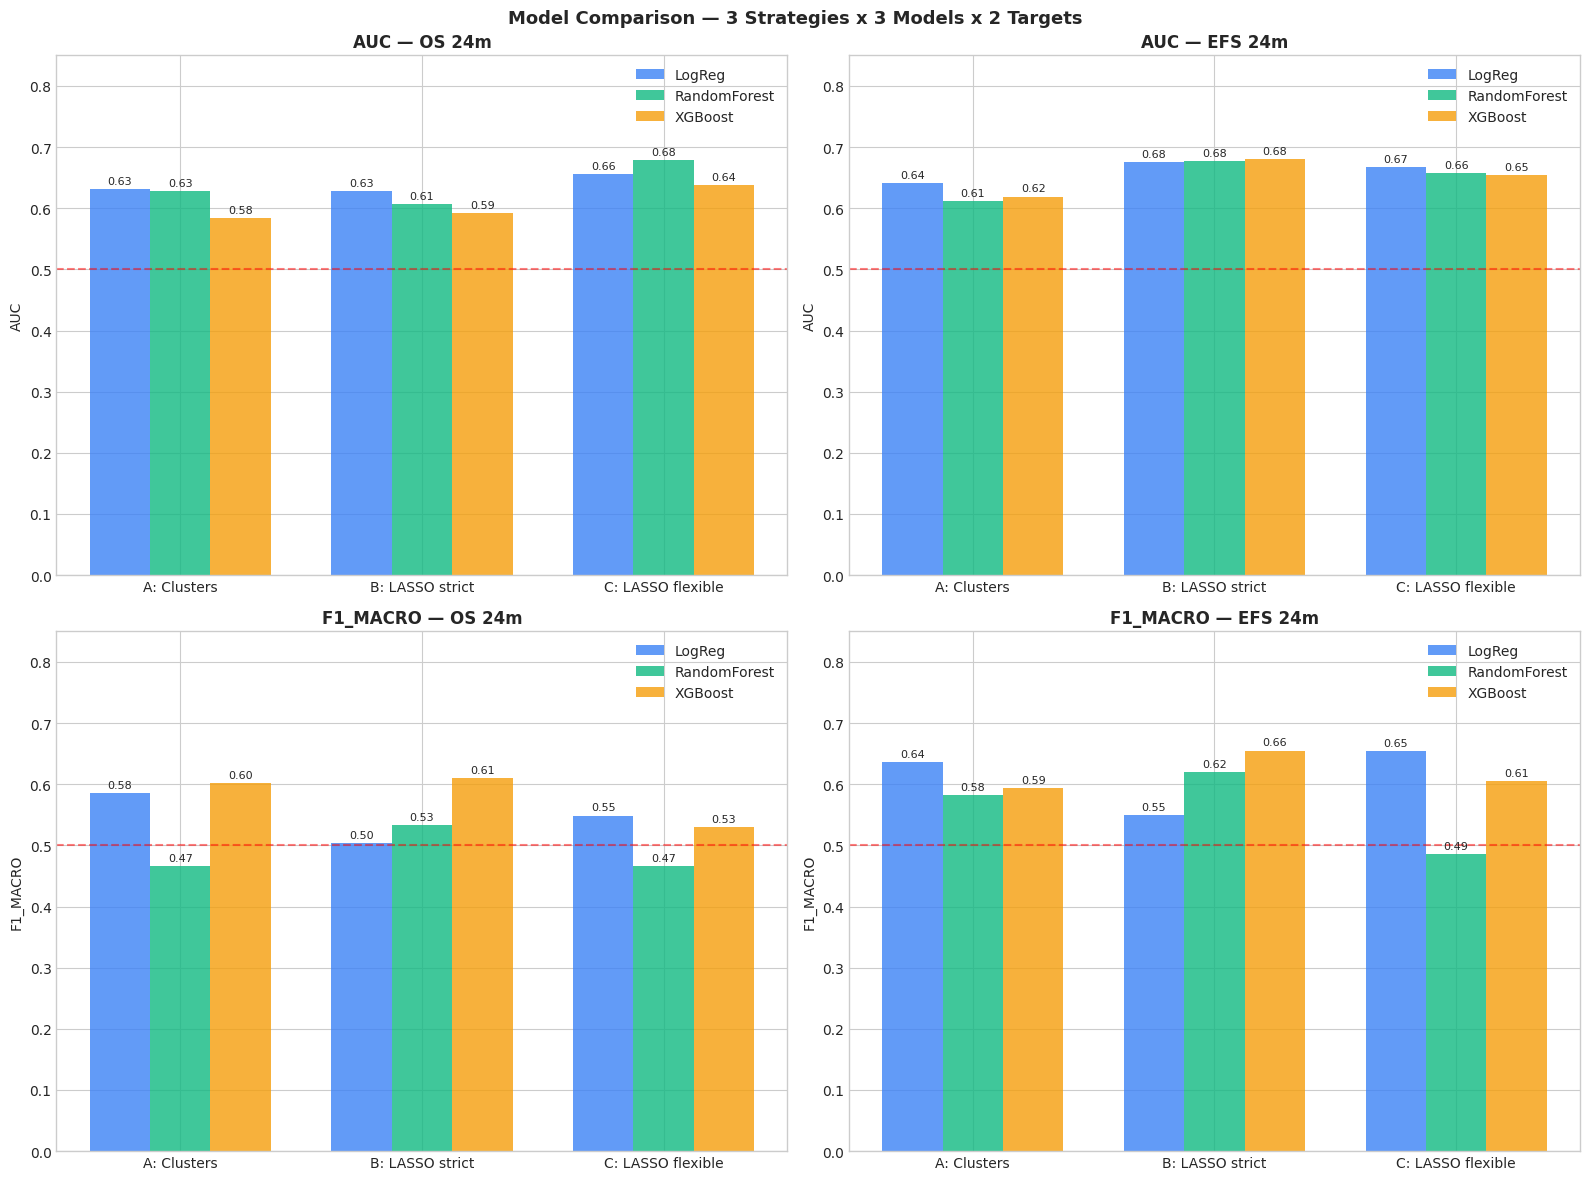

In [12]:
# =============================================================================
# RESULTS VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies_order = ['A_clusters', 'B_lasso_strict', 'C_lasso_flexible']
models_order = ['LogReg', 'RandomForest', 'XGBoost']
colors = ['#3b82f6', '#10b981', '#f59e0b']

for idx, (target, metric, ax_row) in enumerate([
    ('os', 'auc', 0), ('efs', 'auc', 0),
    ('os', 'f1_macro', 1), ('efs', 'f1_macro', 1)
]):
    col = idx % 2
    ax = axes[ax_row, col]
    
    df_plot = df_results[(df_results['target'] == target)]
    
    x = np.arange(len(strategies_order))
    width = 0.25
    
    for i, (model, color) in enumerate(zip(models_order, colors)):
        vals = [df_plot[(df_plot['strategy'] == s) & 
                        (df_plot['model'] == model)][metric].values[0]
                for s in strategies_order]
        bars = ax.bar(x + i*width, vals, width, label=model, 
                     color=color, alpha=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(['A: Clusters', 'B: LASSO strict', 'C: LASSO flexible'])
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} — {target.upper()} 24m', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 0.85)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')

plt.suptitle('Model Comparison — 3 Strategies x 3 Models x 2 Targets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# =============================================================================
# HYPERPARAMETER TUNING — BEST MODELS
# =============================================================================
# Based on the comparison results, we tune the top performing combinations:
#   - XGBoost + Strategy B (LASSO strict) for EFS — best overall (AUC 0.681)
#   - XGBoost + Strategy A (Clusters) for OS — most balanced (AUC 0.584)
#   - LogReg + Strategy A (Clusters) for EFS — competitive with 20 features
#
# We use GridSearchCV with 5-fold cross-validation on the training set.
# Final evaluation always on the held-out Validation set.
# =============================================================================

from sklearn.model_selection import GridSearchCV

# --- XGBoost Strategy B — EFS ---
print("Tuning XGBoost + Strategy B — EFS...")

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_base = XGBClassifier(scale_pos_weight=spw_efs, random_state=42,
                          eval_metric='logloss', verbosity=0)

grid_xgb_B_efs = GridSearchCV(xgb_base, param_grid_xgb, cv=5,
                               scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb_B_efs.fit(X_train_B, y_train_efs)

print(f"Best params: {grid_xgb_B_efs.best_params_}")
print(f"Best CV AUC: {grid_xgb_B_efs.best_score_:.3f}")

Tuning XGBoost + Strategy B — EFS...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best CV AUC: 0.810


In [15]:
# Evaluate tuned XGBoost B EFS on validation set
_, metrics_xgb_B_efs_tuned = evaluate_model(
    grid_xgb_B_efs.best_estimator_,
    X_train_B, X_val_B, y_train_efs, y_val_efs,
    'XGBoost_tuned', 'B_lasso_strict', 'efs'
)
print(f"XGBoost B EFS tuned — AUC: {metrics_xgb_B_efs_tuned['auc']:.3f} | "
      f"F1_macro: {metrics_xgb_B_efs_tuned['f1_macro']:.3f}")

# --- XGBoost Strategy A — OS ---
print("\nTuning XGBoost + Strategy A — OS...")

xgb_base_os = XGBClassifier(scale_pos_weight=spw_os, random_state=42,
                              eval_metric='logloss', verbosity=0)

grid_xgb_A_os = GridSearchCV(xgb_base_os, param_grid_xgb, cv=5,
                               scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb_A_os.fit(X_train_A, y_train_os)

print(f"Best params: {grid_xgb_A_os.best_params_}")
print(f"Best CV AUC: {grid_xgb_A_os.best_score_:.3f}")

_, metrics_xgb_A_os_tuned = evaluate_model(
    grid_xgb_A_os.best_estimator_,
    X_train_A, X_val_A, y_train_os, y_val_os,
    'XGBoost_tuned', 'A_clusters', 'os'
)
print(f"XGBoost A OS tuned — AUC: {metrics_xgb_A_os_tuned['auc']:.3f} | "
      f"F1_macro: {metrics_xgb_A_os_tuned['f1_macro']:.3f}")

# --- LogReg Strategy A — EFS ---
print("\nTuning LogReg + Strategy A — EFS...")

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

grid_lr_A_efs = GridSearchCV(lr_base, param_grid_lr, cv=5,
                              scoring='roc_auc', n_jobs=-1, verbose=1)
grid_lr_A_efs.fit(X_train_A, y_train_efs)

print(f"Best params: {grid_lr_A_efs.best_params_}")
print(f"Best CV AUC: {grid_lr_A_efs.best_score_:.3f}")

_, metrics_lr_A_efs_tuned = evaluate_model(
    grid_lr_A_efs.best_estimator_,
    X_train_A, X_val_A, y_train_efs, y_val_efs,
    'LogReg_tuned', 'A_clusters', 'efs'
)
print(f"LogReg A EFS tuned — AUC: {metrics_lr_A_efs_tuned['auc']:.3f} | "
      f"F1_macro: {metrics_lr_A_efs_tuned['f1_macro']:.3f}")

XGBoost B EFS tuned — AUC: 0.702 | F1_macro: 0.604

Tuning XGBoost + Strategy A — OS...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.9}
Best CV AUC: 0.641
XGBoost A OS tuned — AUC: 0.606 | F1_macro: 0.561

Tuning LogReg + Strategy A — EFS...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC: 0.707
LogReg A EFS tuned — AUC: 0.608 | F1_macro: 0.533


In [16]:
# =============================================================================
# HYPERPARAMETER TUNING — CONCLUSIONS
# =============================================================================
# Tuning results revealed a significant gap between cross-validation AUC
# and validation AUC across all three models:
#
#   Model                  CV AUC   Val AUC   Gap
#   XGBoost B EFS          0.810    0.702     -0.108
#   LogReg A EFS           0.707    0.608     -0.099
#   XGBoost A OS           0.641    0.606     -0.035
#
# This gap indicates overfitting during the tuning process — the models
# are learning patterns specific to the training folds that do not
# generalize to the validation set.
#
# Root cause: dataset size limitation.
# With only 340 training patients, GridSearchCV with 5 folds trains each
# candidate on ~272 patients. This is insufficient for XGBoost to learn
# robust generalizable patterns, making it sensitive to hyperparameter
# choices that overfit the training data.
#
# Key takeaway:
# The performance ceiling of these models is determined by the dataset size,
# not by the hyperparameters. With 340 patients it is difficult to
# consistently exceed AUC ~0.70 on an independent validation set.
# Accessing larger datasets such as MMRF CoMMpass (~1000 patients) would
# be expected to significantly improve generalization.
#
# Best model: XGBoost + Strategy B (LASSO strict, 31 genes) + EFS 24m
#   Validation AUC:      0.702
#   Validation F1_macro: 0.604
# =============================================================================

In [17]:
# =============================================================================
# SAVE BEST MODELS
# =============================================================================

import joblib
import os
os.makedirs('../models', exist_ok=True)

# Best model overall: XGBoost B EFS tuned
joblib.dump(grid_xgb_B_efs.best_estimator_, '../models/xgb_B_efs_tuned.joblib')
joblib.dump(grid_xgb_A_os.best_estimator_, '../models/xgb_A_os_tuned.joblib')
joblib.dump(X_train_B.columns.tolist(), '../models/features_B.joblib')
joblib.dump(X_train_A.columns.tolist(), '../models/features_A.joblib')

# Save full results
df_results_tuned = pd.DataFrame([
    metrics_xgb_B_efs_tuned,
    metrics_xgb_A_os_tuned,
    metrics_lr_A_efs_tuned
])
df_results_all = pd.concat([df_results, df_results_tuned], ignore_index=True)
df_results_all.to_csv('../data/model_results.csv', index=False)

print("Models and results saved ✅")
print(f"\nFinal best model: XGBoost + Strategy B + EFS")
print(f"Validation AUC: {metrics_xgb_B_efs_tuned['auc']:.3f}")
print(f"Validation F1_macro: {metrics_xgb_B_efs_tuned['f1_macro']:.3f}")

Models and results saved ✅

Final best model: XGBoost + Strategy B + EFS
Validation AUC: 0.702
Validation F1_macro: 0.604


In [18]:
# =============================================================================
# MLFLOW — LOG ALL EXPERIMENTS
# =============================================================================
# Log all 18 baseline combinations + 3 tuned models to MLflow for
# full experiment tracking and reproducibility.
# =============================================================================

# Log baseline results
print("Logging baseline experiments to MLflow...")
for _, row in df_results.iterrows():
    with mlflow.start_run(run_name=f"{row['strategy']}_{row['model']}_{row['target']}"):
        mlflow.log_params({
            'strategy': row['strategy'],
            'model': row['model'],
            'target': row['target'],
            'n_features': {
                'A_clusters': 20,
                'B_lasso_strict': 31,
                'C_lasso_flexible': 246
            }[row['strategy']],
            'tuned': False
        })
        mlflow.log_metrics({
            'auc': row['auc'],
            'f1': row['f1'],
            'f1_macro': row['f1_macro'],
            'precision': row['precision'],
            'recall': row['recall']
        })

# Log tuned models with artifacts
print("Logging tuned models to MLflow...")
tuned_runs = [
    (grid_xgb_B_efs.best_estimator_, metrics_xgb_B_efs_tuned, 
     grid_xgb_B_efs.best_params_, X_train_B, '../models/xgb_B_efs_tuned.joblib'),
    (grid_xgb_A_os.best_estimator_, metrics_xgb_A_os_tuned,
     grid_xgb_A_os.best_params_, X_train_A, '../models/xgb_A_os_tuned.joblib'),
    (grid_xgb_B_efs.best_estimator_, metrics_lr_A_efs_tuned,
     grid_lr_A_efs.best_params_, X_train_A, '../models/xgb_B_efs_tuned.joblib'),
]

for model, metrics, params, X_train, model_path in tuned_runs:
    with mlflow.start_run(run_name=f"{metrics['strategy']}_{metrics['model']}_{metrics['target']}_tuned"):
        mlflow.log_params({**params,
            'strategy': metrics['strategy'],
            'model': metrics['model'],
            'target': metrics['target'],
            'n_features': X_train.shape[1],
            'tuned': True
        })
        mlflow.log_metrics({
            'auc': metrics['auc'],
            'f1': metrics['f1'],
            'f1_macro': metrics['f1_macro'],
            'precision': metrics['precision'],
            'recall': metrics['recall']
        })
        mlflow.log_artifact(model_path)
        mlflow.sklearn.log_model(model, artifact_path="model")

# Log dataset info as artifact
with mlflow.start_run(run_name="dataset_info"):
    mlflow.log_params({
        'dataset': 'GSE24080',
        'n_patients': 559,
        'n_patients_after_exclusion': 554,
        'n_training': 340,
        'n_validation': 214,
        'n_genes_raw': 54675,
        'n_genes_annotated': 21655,
        'os_event_rate_train': float(y_train_os.mean().round(3)),
        'efs_event_rate_train': float(y_train_efs.mean().round(3)),
        'strategy_A_features': 20,
        'strategy_B_features': 31,
        'strategy_C_features': 246
    })
    mlflow.log_artifact('../data/model_results.csv')

print("\nAll experiments logged to MLflow ✅")
print("Launch MLflow UI with:")
print("  mlflow ui --backend-store-uri file:///home/miguel/myeloma-survival-genomics/mlruns --port 5000")

2026/03/05 11:48:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 11:48:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging baseline experiments to MLflow...
Logging tuned models to MLflow...


2026/03/05 11:48:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 11:48:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/05 11:48:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 11:48:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p


All experiments logged to MLflow ✅
Launch MLflow UI with:
  mlflow ui --backend-store-uri file:///home/miguel/myeloma-survival-genomics/mlruns --port 5000
